<a href="https://colab.research.google.com/github/lazic7/MSAP/blob/master/LV4_ponavljanje.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

In [96]:
df = pd.read_csv("AirQualityUCI.csv")
df = df.drop(columns=["Unnamed: 15", "Unnamed: 16"], errors="ignore")
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,3/10/2004,18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,3/10/2004,19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,3/10/2004,20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,3/10/2004,21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,3/10/2004,22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


In [97]:
df.tail()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
9466,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9467,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9468,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9469,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9470,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
dtypes: float64(13), object(2)
memory usage: 1.1+ MB


In [99]:
df.describe()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000
mean,-34.207524,1048.990061,-159.090093,1.865683,894.595276,168.616971,794.990168,58.148873,1391.479641,975.072032,9.778305,39.485380,-6.837604
std,77.657170,329.832710,139.789093,41.380206,342.333252,257.433866,321.993552,126.940455,467.210125,456.938184,43.203623,51.216145,38.976670
min,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000
25%,0.600000,921.000000,-200.000000,4.000000,711.000000,50.000000,637.000000,53.000000,1185.000000,700.000000,10.900000,34.100000,0.692300
50%,1.500000,1053.000000,-200.000000,7.900000,895.000000,141.000000,794.000000,96.000000,1446.000000,942.000000,17.200000,48.600000,0.976800
75%,2.600000,1221.000000,-200.000000,13.600000,1105.000000,284.000000,960.000000,133.000000,1662.000000,1255.000000,24.100000,61.900000,1.296200
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000


-200 nije “prava” izmjerena vrijednost nego kod za missing, pa ga moramo tretirati kao NaN.
Ne želimo baciti cijeli dataset zbog NaN u stupcima koje ne koristimo, zato brišemo retke s NaN samo za odabrani X i Y

In [100]:
df = df.replace(-200, np.nan)
df = df.apply(pd.to_numeric, errors="coerce")
df.isna().sum()

,0
Date,9471
Time,9471
CO(GT),1797
PT08.S1(CO),480
NMHC(GT),8557
C6H6(GT),480
PT08.S2(NMHC),480
NOx(GT),1753
PT08.S3(NOx),480
NO2(GT),1756


In [101]:
print(f"Broj redaka prije ciscenja", df.shape[0])
df_model = df[['C6H6(GT)', 'CO(GT)']].dropna()
print(f"Broj redaka nakon ciscenja", df_model.shape[0])

Broj redaka prije ciscenja 9471
Broj redaka nakon ciscenja 7344


Zašto je ovo dobar par?

oba su zagađivači povezani s prometom/izgaranjem → često rastu/padaju zajedno

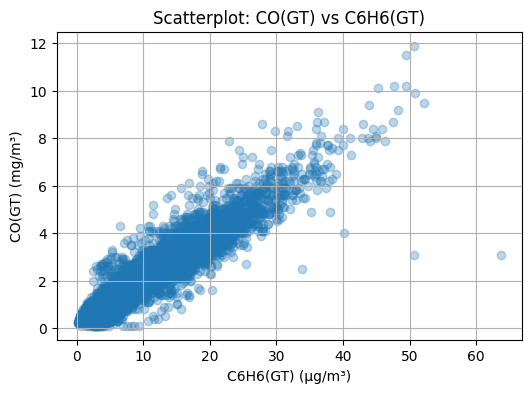

In [102]:
plt.figure(figsize=(6,4))
plt.scatter(df_model['C6H6(GT)'], df_model['CO(GT)'], alpha=0.3)
plt.xlabel("C6H6(GT) (µg/m³)")
plt.ylabel("CO(GT) (mg/m³)")
plt.title("Scatterplot: CO(GT) vs C6H6(GT)")
plt.grid(True)
plt.show()

Model jednostavne linearne regresije:

Y=β0+β1X+ε

Za naš odabir varijabli:

CO(GT)=β0​+β1​⋅C6H6(GT)+ε

Ciljna varijabla (Y): CO(GT) — koncentracija ugljičnog monoksida (mg/m³)

Nezavisna varijabla (X): C6H6(GT) — koncentracija benzena (µg/m³)

Hipoteze:

H0​:β1​=0 H1​:β1​!=0

Uz α=0.05


**Izgradnja linearnog regresijskog modela**

In [103]:
X = df_model['C6H6(GT)']
Y = df_model['CO(GT)']
slope, intercept, r_value, p_value, std_err = stats.linregress(X, Y)

print(f"Nagib (slope): {slope:.4f}")
print(f"Odsječak (intercept): {intercept:.4f}")
print(f"P vrijednost: {p_value:.4f}")
print(f"Koeficijent determinacije (R^2): {r_value**2:.4f}")

Nagib (slope): 0.1797
Odsječak (intercept): 0.2827
P vrijednost: 0.0000
Koeficijent determinacije (R^2): 0.8669


In [104]:

X_sm = sm.add_constant(X)  # dodaje stupac 1 za β0
model = sm.OLS(Y, X_sm).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 CO(GT)   R-squared:                       0.867
Model:                            OLS   Adj. R-squared:                  0.867
Method:                 Least Squares   F-statistic:                 4.782e+04
Date:                Sat, 10 Jan 2026   Prob (F-statistic):               0.00
Time:                        15:00:33   Log-Likelihood:                -5674.8
No. Observations:                7344   AIC:                         1.135e+04
Df Residuals:                    7342   BIC:                         1.137e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2827      0.010     27.114      0.0

Skaliranje nije provedeno jer se koristi jednostavna linearna regresija i interpretacija koeficijenata u originalnim jedinicama je poželjna.

In [105]:
y_predicted = intercept + slope * X

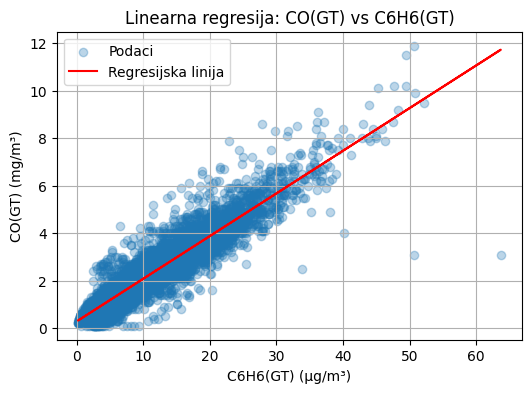

In [106]:
plt.figure(figsize=(6,4))
plt.scatter(X, Y, alpha=0.3, label="Podaci")
plt.plot(X, y_predicted, color="red", label="Regresijska linija")

plt.xlabel("C6H6(GT) (µg/m³)")
plt.ylabel("CO(GT) (mg/m³)")
plt.title("Linearna regresija: CO(GT) vs C6H6(GT)")
plt.legend()
plt.grid(True)
plt.show()

Nagib (slope): 0.1797

Odsječak (intercept): 0.2827

Koeficijent determinacije (R^2): 0.8669

Ako se koncentracija benzena C6H6(GT) poveća za 1 µg/m³, očekivana koncentracija CO(GT) poraste za približno 0.18 mg/m³, u prosjeku.

Odsječak predstavlja procijenjenu vrijednost CO(GT) kada je C6H6(GT) = 0.
Iako ta situacija možda nema fizičko značenje, odsječak je potreban za matematički opis modela.

Oko 87% varijabilnosti koncentracije CO(GT) može se objasniti linearnom vezom s koncentracijom C6H6(GT).
Preostali dio varijabilnosti posljedica je drugih čimbenika i slučajne pogreške.

**Intervali povjerenja za parametre**

In [107]:
#Interval povjerenja za populacijski nagib
confidence_level = 0.95
n = df_model.shape[0]
t_critical = stats.t.ppf((1 + confidence_level) / 2, df=n-2)
margin_of_error = t_critical * std_err
lower_bound = slope - margin_of_error
upper_bound = slope + margin_of_error

print(f"Interval povjerenja za populacijski nagib ({confidence_level*100}%): ({lower_bound:.4f}, {upper_bound:.4f})")

Interval povjerenja za populacijski nagib (95.0%): (0.1781, 0.1814)


In [108]:
ci = model.conf_int(alpha=0.05)   # 95% CI
ci.index = ["β0 (const)", "β1 (C6H6(GT))"]
ci.columns = ["donja granica", "gornja granica"]
ci

,donja granica,gornja granica
β0 (const),0.262296,0.303178
β1 (C6H6(GT)),0.178130,0.181353


95% interval povjerenja za populacijski nagib β1 iznosi (0.178, 0.181). Budući da interval ne sadrži 0, odbacujemo nul-hipotezu H0: β1 = 0 na razini značajnosti 0.05 te zaključujemo da postoji statistički značajna linearna veza između C6H6(GT) i CO(GT).

**Analiza adekvatnosti modela**

In [109]:
residuals = df_model['CO(GT)'] - (intercept + slope * df_model['C6H6(GT)'])

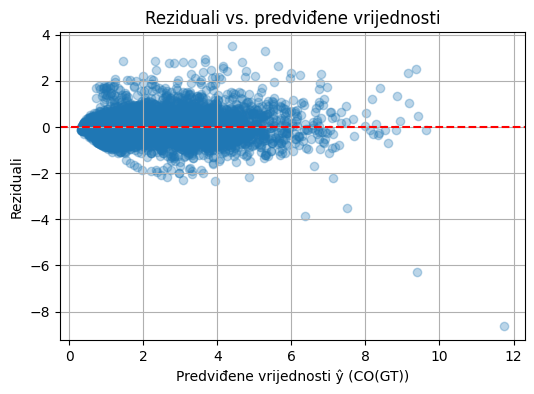

In [110]:
plt.figure(figsize=(6,4))
plt.scatter(y_predicted, residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predviđene vrijednosti ŷ (CO(GT))")
plt.ylabel("Reziduali")
plt.title("Reziduali vs. predviđene vrijednosti")
plt.grid(True)
plt.show()

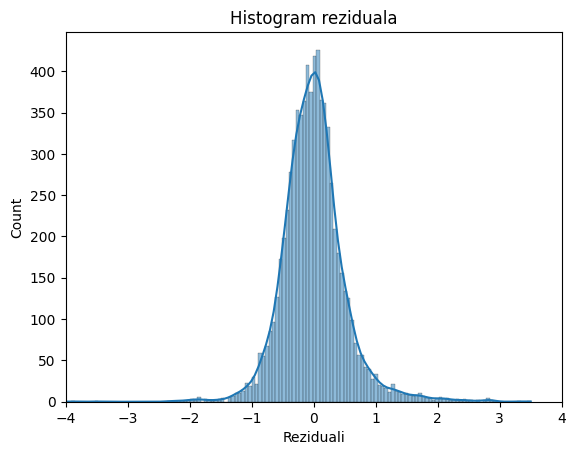

In [111]:
sns.histplot(residuals, kde=True)
plt.xlabel('Reziduali')
plt.title('Histogram reziduala')
plt.xlim(-4,4)
plt.show()

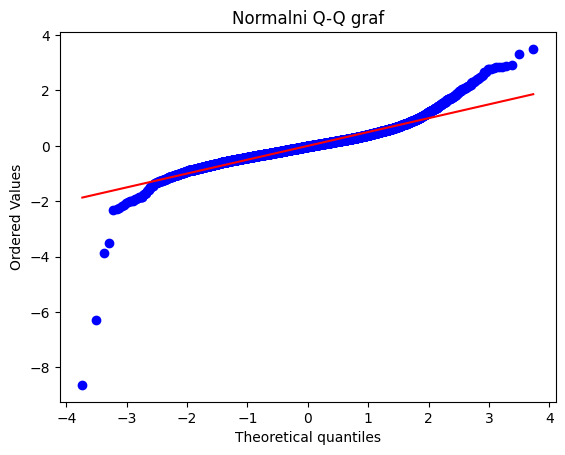

In [112]:
plt.figure()
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Normalni Q-Q graf')
plt.show()

Reziduali su u prosjeku raspoređeni oko nule, bez izraženog trenda ili zakrivljenosti, što upućuje da je linearni oblik modela primjeren. Reziduali nisu jednako raspršeni za sve predviđene vrijednosti. Vidljivo je povećanje varijance reziduala s porastom predviđenih vrijednosti, što ukazuje na heteroskedastičnost. Iako to ne utječe na nepristranost procjena, može utjecati na standardne pogreške.

QQ-plot pokazuje da reziduali u središnjem dijelu približno slijede normalnu razdiobu, dok su u repovima vidljiva odstupanja. To upućuje na blago kršenje pretpostavke normalnosti, što je očekivano kod velikih realnih skupova podataka.

Koeficijent determinacije iznosi R² ≈ 0.87, što znači da oko 87% varijabilnosti koncentracije CO(GT) može biti objašnjeno linearnim odnosom s koncentracijom C6H6(GT). S obzirom na kompleksnost procesa koji utječu na kvalitetu zraka, ovakva vrijednost R² može se smatrati vrlo zadovoljavajućom.

**Koeficijent korelacije**

In [113]:
r_pearson, p_value_scipy = stats.pearsonr(X, Y)

print(f"Pearsonov koeficijent korelacije r = {r_pearson:.4f}")
print(f"p-vrijednost (iz scipy.pearsonr) = {p_value_scipy:.6f}")

Pearsonov koeficijent korelacije r = 0.9311
p-vrijednost (iz scipy.pearsonr) = 0.000000


r = 0.93 → jaka pozitivna linearna veza

Kako se koncentracija C6H6(GT) povećava, u prosjeku se povećava i koncentracija CO(GT).

Za jednostavnu linearnu regresiju vrijedi:

R^2=r^2

In [115]:
print(f"Koeficijent determinacije (R^2): {r_value**2:.4f}")
print(f"Pearsonov koeficijent korelacije r = {r_pearson**2:.4f}")

Koeficijent determinacije (R^2): 0.8669
Pearsonov koeficijent korelacije r = 0.8669


Kvadrat Pearsonovog koeficijenta korelacije jednak je koeficijentu determinacije regresijskog modela, što potvrđuje dosljednost između korelacijske i regresijske analize.

**Testiranje adekvatnosti modela – F-test**

In [117]:
F_stat = model.fvalue
p_F = model.f_pvalue

print(f"F statistika: {F_stat:.4f}")
print(f"P vrijednost: {p_F:.4f}")

F statistika: 47822.3706
P vrijednost: 0.0000


F-test regresijskog modela daje F-statistiku F ≈ 4.78·10⁴ uz pripadnu p-vrijednost manju od 0.05. Na razini značajnosti α = 0.05 odbacujemo nul-hipotezu da model nema objašnjavačku moć te zaključujemo da je regresijski model statistički značajan.

**Deskriptivna statistika**

In [123]:
vars_desc = ["CO(GT)", "NO2(GT)", "T", "RH"]

df_desc = df[vars_desc].dropna()

In [124]:
df_desc.describe()

,CO(GT),NO2(GT),T,RH
count,6941.000000,6941.000000,6941.000000,6941.000000
mean,2.182467,113.874082,17.755323,48.881905
std,1.441158,47.475017,8.844909,17.433193
min,0.100000,2.000000,-1.900000,9.200000
25%,1.100000,79.000000,11.200000,35.300000
50%,1.900000,110.000000,16.800000,49.200000
75%,2.900000,142.000000,23.700000,62.200000
max,11.900000,333.000000,44.600000,88.700000


In [125]:
df_desc.mode()

,CO(GT),NO2(GT),T,RH
0,1.0,110.0,12.0,47.8
1,NaN,119.0,NaN,NaN


In [126]:
df_desc.median()

,0
CO(GT),1.9
NO2(GT),110.0
T,16.8
RH,49.2


Srednja vrijednost CO u grupi podataka je oko 2.18 mg/m^3 uz standardnu devijaciju od 1.4 mg/m^3. U 75% slucajeva zabiljezena vrijednost CO je 2.9 mg/m^3 dok je namjanja zabiljezena vrijednost 0.1 mg/m^3

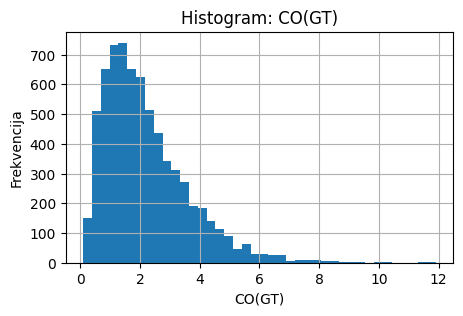

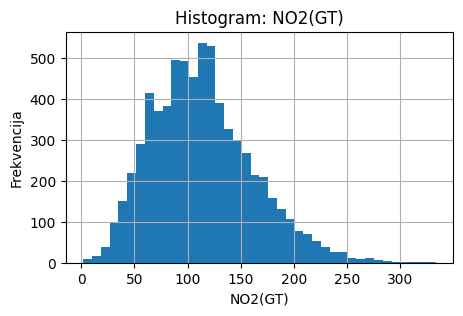

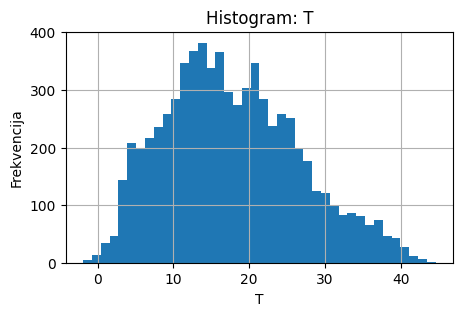

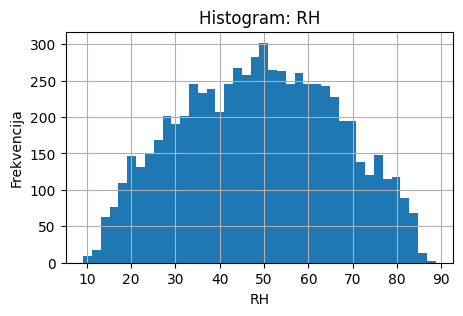

In [127]:
for col in vars_desc:
    plt.figure(figsize=(5,3))
    plt.hist(df_desc[col], bins=40)
    plt.title(f"Histogram: {col}")
    plt.xlabel(col)
    plt.ylabel("Frekvencija")
    plt.grid(True)
    plt.show()

/tmp/ipython-input-2901669640.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df_desc[col] for col in vars_desc], labels=vars_desc)


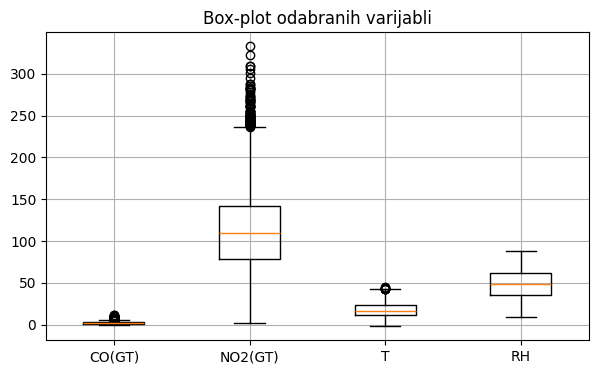

In [128]:
plt.figure(figsize=(7,4))
plt.boxplot([df_desc[col] for col in vars_desc], labels=vars_desc)
plt.title("Box-plot odabranih varijabli")
plt.grid(True)
plt.show()